## Initial Setting 

In [1]:
# 📊 DATA MANIPULATION & ANALYSIS LIBRARIES
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, pearsonr

# 📈 DATA VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 🤖 MACHINE LEARNING & MODELING LIBRARIES
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, confusion_matrix, 
    classification_report, roc_auc_score, silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 🔧 UTILITY & SYSTEM LIBRARIES
import os
import warnings
from datetime import datetime
import re
from collections import Counter

# 🎨 VISUALIZATION SETUP
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Plotly settings
import plotly.io as pio
pio.templates.default = "plotly_white"

# 📏 DISPLAY OPTIONS
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# ⚠️ WARNINGS CONFIGURATION
warnings.filterwarnings('ignore')


In [2]:
!pip install gradio

In [3]:
import numpy as np
import sklearn
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)


numpy: 2.4.2
sklearn: 1.8.0


In [4]:
import gradio as gr

## Importing The data

In [5]:
try:
    df = pd.read_csv(r"C:\Users\v\Downloads\archive\bi.csv", encoding='latin-1')
    print("✅ Loaded with latin-1 encoding!")
except:
    pass

✅ Loaded with latin-1 encoding!


## Data Cleaning and Preprocessing

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     str    
 1   lNAME          77 non-null     str    
 2   Age            77 non-null     int64  
 3   gender         77 non-null     str    
 4   country        77 non-null     str    
 5   residence      77 non-null     str    
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     str    
 8   studyHOURS     77 non-null     int64  
 9   Python         75 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 6.7 KB


In [7]:
df.describe()

,Age,entryEXAM,studyHOURS,Python,DB
count,77.00,77.00,77.00,75.00,77.00
mean,35.21,76.75,149.71,75.85,69.47
std,10.34,16.48,12.74,15.41,17.03
min,21.00,28.00,114.00,15.00,30.00
25%,27.00,69.00,144.00,71.00,56.00
50%,33.00,80.00,156.00,81.00,71.00
75%,42.00,90.00,158.00,85.00,83.00
max,71.00,98.00,160.00,91.00,100.00


In [8]:
df.isnull().sum()

fNAME            0
lNAME            0
Age              0
gender           0
country          0
residence        0
entryEXAM        0
prevEducation    0
studyHOURS       0
Python           2
DB               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Python"] = df["Python"].fillna(df["Python"].mean())
df.isnull().sum()

fNAME            0
lNAME            0
Age              0
gender           0
country          0
residence        0
entryEXAM        0
prevEducation    0
studyHOURS       0
Python           0
DB               0
dtype: int64

In [11]:
string_columns = df.select_dtypes(include=['object']).columns.tolist()

print("🔍 UNIQUE VALUES IN STRING COLUMNS")
print("=" * 50)

for col in string_columns:
    unique_values = df[col].unique()
    print(f"\n📊 {col}:")
    print(f"   Unique count: {len(unique_values)}")
    print(f"   Values: {list(unique_values)}")

🔍 UNIQUE VALUES IN STRING COLUMNS

📊 fNAME:
   Unique count: 71
   Values: ['Christina', 'Alex', 'Philip', 'Shoni', 'Maria', 'Hannah', 'Ole', 'Lars', 'Bjørn', 'Sofie', 'Emma', 'Solveig', 'Odd', 'Grethe', 'Marco', 'Ingrid', 'Hanna', 'Jorunn', 'Sebastian', 'Camilla', 'Prof', 'Kristine', 'Carmen', 'Gunnar', 'Gerd', 'Aisha', 'Kato', 'Nansubuga', 'Joakim', 'Don', 'Perry', 'Frank', 'Line', 'Thor', 'Petter', 'Sindre', 'Simen', 'Bjørg', 'Trond', 'Emily', 'Unni', 'Ruth', 'Inger', 'Peninah', 'Berit', 'Jenny', 'Thea', 'Dag', 'Mwanaidi', 'Chinedu', 'Irene', 'Marianne', 'Jens', 'Morten', 'Karoline', 'Ola', 'Tore', 'Caroline', 'Silvia', 'Valentino', 'Peter', 'Anna', 'Lucas', 'Marie', 'Thomas', 'Maximilan', 'Clara', 'Julian', 'Sophie', 'Leon', 'Mohammed']

📊 lNAME:
   Unique count: 66
   Values: ['Binger', 'Walekhwa', 'Leo', 'Hlongwane', 'Kedibone', 'Hansen', 'Johansen', 'Olsen', 'Larsen', 'Jensen', 'de Vries', 'Eliassen', 'Knudsen', 'Myklebust', 'Rossi', 'Eide', 'Andresen', 'Kristiansen', 'Mikkelsen

In [12]:
df['gender'] = df['gender'].replace({
    'M': 'Male', 'F': 'Female', 'male': 'Male', 'female': 'Female'
})

In [13]:
df['country'] = df['country'].replace({
    'Norway': 'Norway', 'Norge': 'Norway', 
    'Rsa': 'South Africa', 'UK': 'United Kingdom',
    'Somali': 'Somalia'
})

In [14]:
df['residence'] = df['residence'].replace({
    'BI-Residence': 'BI Residence',
    'BIResidence': 'BI Residence',
    'BI_Residence': 'BI Residence'
})


In [15]:
df['prevEducation'] = df['prevEducation'].replace({
    'Barrrchelors': 'Bachelors',
    'Diplomaaa': 'Diploma',
    'diploma': 'Diploma',
    'DIPLOMA': 'Diploma',
    'HighSchool': 'High School'
})

In [16]:
string_columns = df.select_dtypes(include=['object']).columns.tolist()

print("🔍 UNIQUE VALUES IN STRING COLUMNS")
print("=" * 50)

for col in string_columns:
    unique_values = df[col].unique()
    print(f"\n📊 {col}:")
    print(f"   Unique count: {len(unique_values)}")
    print(f"   Values: {list(unique_values)}")

🔍 UNIQUE VALUES IN STRING COLUMNS

📊 fNAME:
   Unique count: 71
   Values: ['Christina', 'Alex', 'Philip', 'Shoni', 'Maria', 'Hannah', 'Ole', 'Lars', 'Bjørn', 'Sofie', 'Emma', 'Solveig', 'Odd', 'Grethe', 'Marco', 'Ingrid', 'Hanna', 'Jorunn', 'Sebastian', 'Camilla', 'Prof', 'Kristine', 'Carmen', 'Gunnar', 'Gerd', 'Aisha', 'Kato', 'Nansubuga', 'Joakim', 'Don', 'Perry', 'Frank', 'Line', 'Thor', 'Petter', 'Sindre', 'Simen', 'Bjørg', 'Trond', 'Emily', 'Unni', 'Ruth', 'Inger', 'Peninah', 'Berit', 'Jenny', 'Thea', 'Dag', 'Mwanaidi', 'Chinedu', 'Irene', 'Marianne', 'Jens', 'Morten', 'Karoline', 'Ola', 'Tore', 'Caroline', 'Silvia', 'Valentino', 'Peter', 'Anna', 'Lucas', 'Marie', 'Thomas', 'Maximilan', 'Clara', 'Julian', 'Sophie', 'Leon', 'Mohammed']

📊 lNAME:
   Unique count: 66
   Values: ['Binger', 'Walekhwa', 'Leo', 'Hlongwane', 'Kedibone', 'Hansen', 'Johansen', 'Olsen', 'Larsen', 'Jensen', 'de Vries', 'Eliassen', 'Knudsen', 'Myklebust', 'Rossi', 'Eide', 'Andresen', 'Kristiansen', 'Mikkelsen

In [17]:
df.columns = df.columns.str.title()
df = df.rename(columns={
    'Fname': 'FName',
    'Lname': 'LName',
    'Entryexam': 'Entry_Exam',
    'Preveducation': 'Prev_Education',
    'Studyhours': 'Study_Hours'
    
})
df.columns

Index(['FName', 'LName', 'Age', 'Gender', 'Country', 'Residence', 'Entry_Exam',
       'Prev_Education', 'Study_Hours', 'Python', 'Db'],
      dtype='str')

## Exploratory Data Analysis

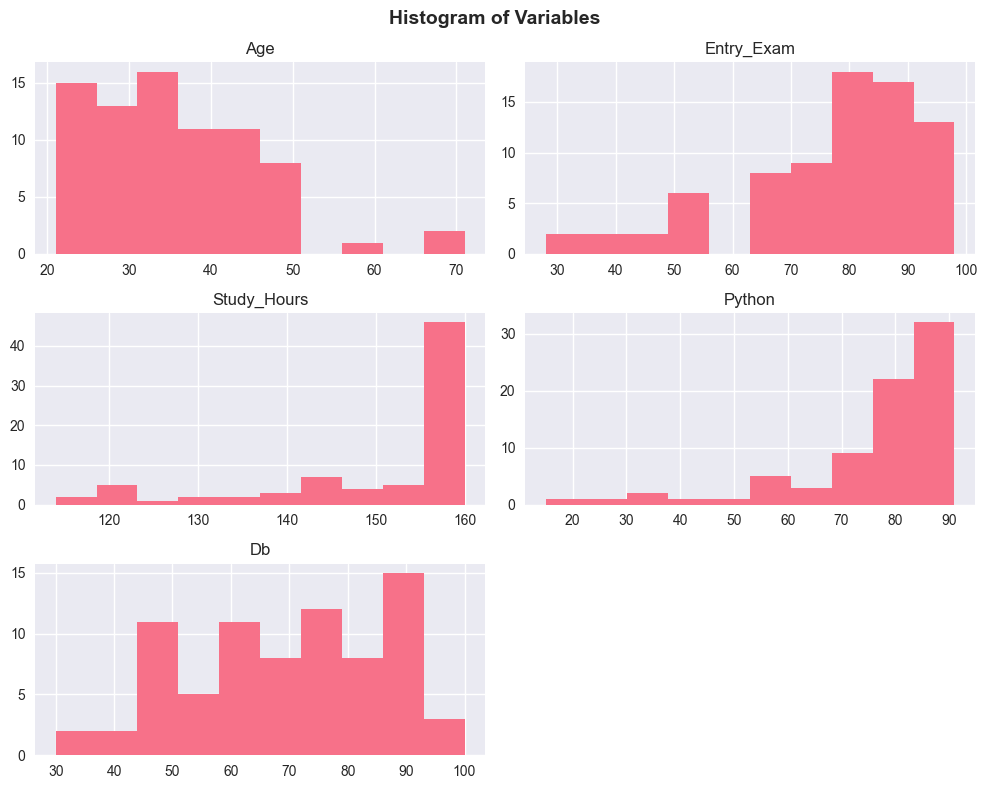

In [18]:
df.hist(figsize=(10,8))
plt.suptitle('Histogram of Variables', fontsize=14, fontweight='bold')
plt.tight_layout()  
plt.show()

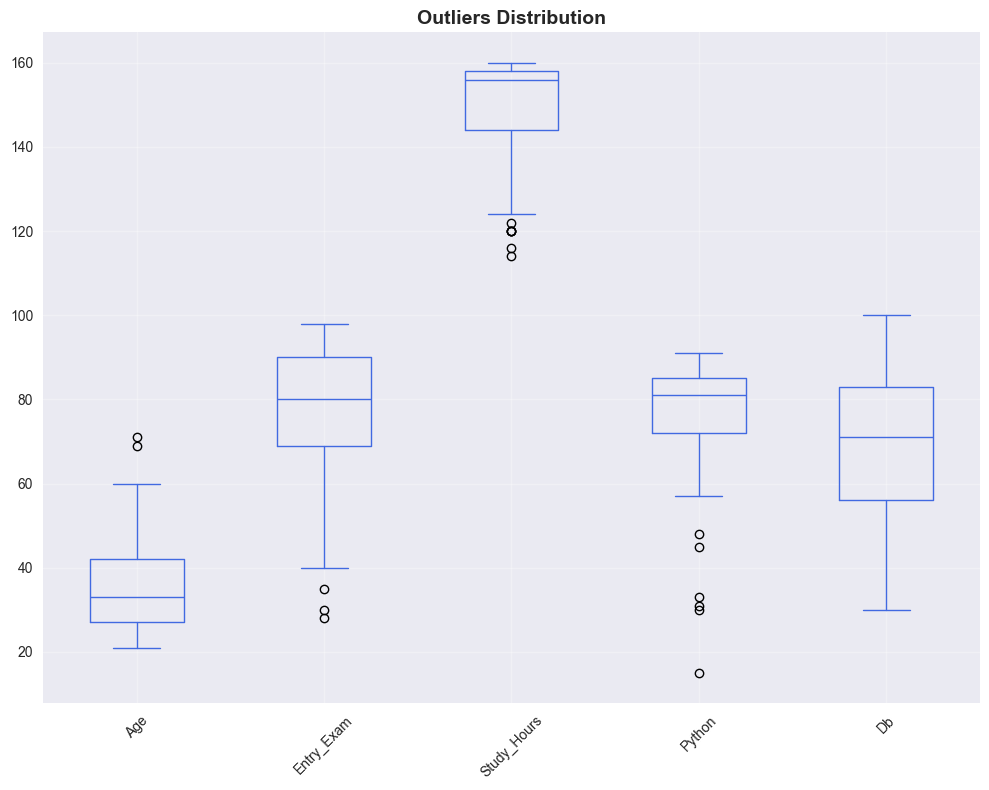

In [19]:
df.boxplot(figsize=(10, 8), color='royalblue')
plt.title('Outliers Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Predictive Modeling

In [20]:
le = LabelEncoder()

# Apply to categorical columns
df['Country'] = le.fit_transform(df['Country']) 

df['Gender'] = le.fit_transform(df['Gender']) 
df['Prev_Education'] = le.fit_transform(df['Prev_Education']) 
df['Residence'] = le.fit_transform(df['Residence'])
print("✅ Categorical columns converted to numbers!")
df

✅ Categorical columns converted to numbers!


,FName,LName,Age,Gender,Country,Residence,Entry_Exam,Prev_Education,Study_Hours,Python,Db
0,Christina,Binger,44,0,7,1,72,4,158,59.00,55
1,Alex,Walekhwa,60,1,4,1,79,1,150,60.00,75
2,Philip,Leo,25,1,11,2,55,3,130,74.00,50
3,Shoni,Hlongwane,22,0,9,2,40,3,120,75.85,44
4,Maria,Kedibone,23,0,9,2,65,3,122,91.00,80
5,Hannah,Hansen,25,0,7,0,66,3,130,88.00,59
6,Ole,Johansen,27,1,7,0,90,0,156,80.00,91
7,Lars,Olsen,29,1,13,0,89,0,160,85.00,60
8,Bjørn,Larsen,31,1,7,0,88,0,156,80.00,89
9,Sofie,Jensen,33,0,0,0,85,0,160,83.00,90


In [21]:
#get student score
df['Total_Percentage'] = ((df['Python'] + df['Db']) / 200) * 100

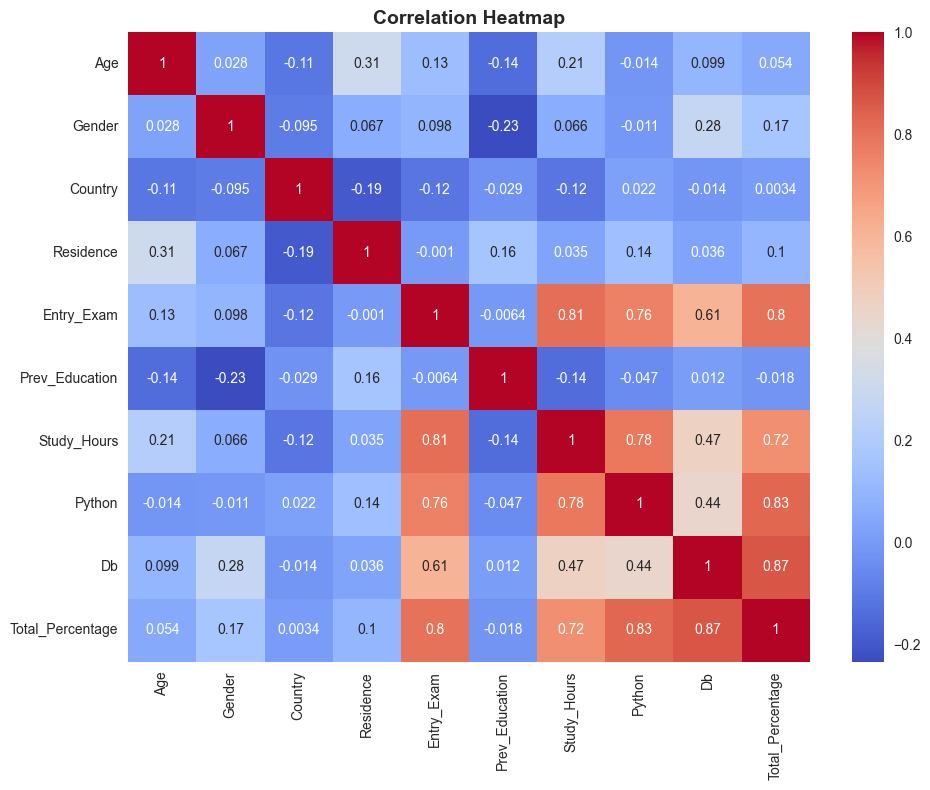

In [22]:
df_numeric=df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['FName', 'LName', 'Age', 'Gender', 'Country', 'Residence', 'Entry_Exam',
       'Prev_Education', 'Study_Hours', 'Python', 'Db', 'Total_Percentage'],
      dtype='str')

In [24]:
X = df.drop(columns=['FName', 'LName','Country','Age','Country',
       'Python', 'Db','Total_Percentage','Prev_Education'])
y = df['Total_Percentage']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print("✅ Data ready for total percentage prediction!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train range: {y_train.min():.1f}% - {y_train.max():.1f}%")

✅ Data ready for total percentage prediction!
X_train: (61, 4), X_test: (16, 4)
y_train range: 31.5% - 93.0%


In [25]:
X_train

,Gender,Residence,Entry_Exam,Study_Hours
9,0,0,85,160
5,0,0,66,130
34,0,0,98,160
22,0,0,55,140
30,1,1,78,152
40,0,1,45,142
39,1,0,68,136
16,0,1,85,156
65,1,2,83,156
54,0,1,80,158


In [26]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train

array([[-8.61891607e-01, -9.97177528e-01,  5.00514120e-01,
         8.26261156e-01],
       [-8.61891607e-01, -9.97177528e-01, -6.83354992e-01,
        -1.55118840e+00],
       [-8.61891607e-01, -9.97177528e-01,  1.31052983e+00,
         8.26261156e-01],
       [-8.61891607e-01, -9.97177528e-01, -1.36875290e+00,
        -7.58705212e-01],
       [ 1.16023870e+00,  4.51104120e-01,  6.43518154e-02,
         1.92274609e-01],
       [-8.61891607e-01,  4.51104120e-01, -1.99184190e+00,
        -6.00208576e-01],
       [ 1.16023870e+00, -9.97177528e-01, -5.58737191e-01,
        -1.07569849e+00],
       [-8.61891607e-01,  4.51104120e-01,  5.00514120e-01,
         5.09267882e-01],
       [ 1.16023870e+00,  1.89938577e+00,  3.75896318e-01,
         5.09267882e-01],
       [-8.61891607e-01,  4.51104120e-01,  1.88969617e-01,
         6.67764519e-01],
       [ 1.16023870e+00,  4.51104120e-01, -6.02659858e-02,
         5.09267882e-01],
       [ 1.16023870e+00, -9.97177528e-01,  7.49749722e-01,
      

In [27]:
def create_models():
    """
    Create multiple machine learning models for regression
    Returns: Dictionary of models
    """
    
    lr_model = LinearRegression()
    rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    knn_model = KNeighborsRegressor(n_neighbors=5)
    dt_model = DecisionTreeRegressor(random_state=42)
    sv_model = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
    
    # All models dictionary
    all_models = {
        "linear_regression": lr_model,
        "random_forest": rf_model,
        "knn": knn_model,
        "decision_tree": dt_model,
        "SVR": sv_model
    }
    
    return all_models

In [28]:
def evaluate_models(models, X_train, X_test, y_train, y_test):
    
    results = {}
    
    print(f"\n MODEL EVALUATION RESULTS")
    print("=" * 80)
    print(f"{'Model':<20} {'MAE':<12} {'RMSE':<14} {'R2':<10}")
    print("-" * 80)
    
    for name, model in models.items():
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        MAE = mean_absolute_error(y_test, pred)
        MSE = mean_squared_error(y_test, pred)    # This is Mean Squared Error
        RMSE = np.sqrt(MSE)                       # This is Root Mean Squared Error
        R2 = r2_score(y_test, pred)
        
        results[name] = {
            "models": model,
            "MAE": MAE,
            "RMSE": RMSE,
            "R2": R2
        }
        print(f"{name:<20} {MAE:.2f}         {RMSE:.2f}          {R2:.2f} ")        
        best_model_name, best_model_values = max(results.items(),  key=lambda x:
                                                (x[1]["R2"],
                                                -x[1]["RMSE"],
                                                -x[1]["MAE"]))
    print("\n")
    print(f"⭐The Best Model : {best_model_name} → MAE: {best_model_values['MAE']:.2f}, "
    f"RMSE: {best_model_values['RMSE']:.2f}, "
    f"R2: {best_model_values['R2']:.2f}")
    
    return 

In [29]:
models = create_models()
results = evaluate_models(models, X_train, X_test, y_train, y_test)
results


 MODEL EVALUATION RESULTS
Model                MAE          RMSE           R2        
--------------------------------------------------------------------------------
linear_regression    7.07         10.03          0.50 
random_forest        5.90         8.56          0.64 
knn                  7.60         9.59          0.55 
decision_tree        6.13         8.84          0.62 
SVR                  7.32         9.41          0.56 


⭐The Best Model : random_forest → MAE: 5.90, RMSE: 8.56, R2: 0.64


In [30]:
import joblib

# Re-train Random Forest (best model) on full data
rf_final = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

# Save model and scaler
joblib.dump(rf_final, 'rf_student_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save label encoding mappings (needed for GUI)
encoding_maps = {
    'Gender':        {'Male': 1, 'Female': 0},          # check your actual le mapping
    'Residence':     {'BI Residence': 0, 'Home': 1, 'Other': 2},  # adjust to your data
}
joblib.dump(encoding_maps, 'encoding_maps.pkl')

print("✅ Model, scaler, and encoders saved!")

✅ Model, scaler, and encoders saved!


In [156]:
import os 

In [160]:
os.getcwd()

'C:\\Users\\v'

In [31]:
import gradio as gr
import joblib
import pandas as pd
import numpy as np

# Load saved artifacts
model = joblib.load('rf_student_model.pkl')
scaler = joblib.load('scaler.pkl')
encoding_maps = joblib.load('encoding_maps.pkl')

FEATURE_ORDER = ['Gender', 'Residence', 'Entry_Exam', 'Study_Hours']
# ⚠️ Match the exact column order X_train had — add any missing columns

def encode_and_predict(row_dict):
    """Encode a dict of raw values and return prediction."""
    for col, mapping in encoding_maps.items():
        if col in row_dict:
            row_dict[col] = mapping.get(row_dict[col], 0)
    df_input = pd.DataFrame([row_dict])[FEATURE_ORDER]
    scaled = scaler.transform(df_input)
    pred = model.predict(scaled)[0]
    return round(pred, 2)

# ── TAB 1: Manual Input ──────────────────────────────────────────────
def predict_single(gender, residence, entry_exam, study_hours):
    row = {
        'Gender':     gender,
        'Residence':  residence,
        'Entry_Exam': entry_exam,
        'Study_Hours':study_hours,
    }
    result = encode_and_predict(row)
    grade = "A" if result>=85 else "B" if result>=70 else "C" if result>=55 else "D"
    return f"📊 Predicted Total Percentage: **{result}%**\n🎓 Grade: {grade}"

# ── TAB 2: File Upload ───────────────────────────────────────────────
def predict_file(file):
    df = pd.read_csv(file.name)
    
    # Encode categorical columns
    for col, mapping in encoding_maps.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0)
    
    X = df[FEATURE_ORDER]
    X_scaled = scaler.transform(X)
    predictions = model.predict(X_scaled)
    
    df['Predicted_Total_Percentage'] = np.round(predictions, 2)
    df['Grade'] = df['Predicted_Total_Percentage'].apply(
        lambda x: "A" if x>=85 else "B" if x>=70 else "C" if x>=55 else "D"
    )
    
    output_path = "predictions_output.csv"
    df.to_csv(output_path, index=False)
    return df[['Predicted_Total_Percentage', 'Grade']].head(20), output_path

# ── BUILD UI ─────────────────────────────────────────────────────────
with gr.Blocks(title="🎓 Student Success Predictor") as app:
    gr.Markdown("# 🎓 Student Total Percentage Predictor\nPowered by Random Forest")

    with gr.Tabs():
        # Tab 1
        with gr.TabItem("📝 Manual Input"):
            with gr.Row():
                gender    = gr.Dropdown(['Male','Female'], label="Gender")
                residence = gr.Dropdown(['BI Residence','Home','Other'], label="Residence")
            with gr.Row():
                entry_exam  = gr.Number(label="Entry Exam Score", minimum=0, maximum=100)
                study_hours = gr.Number(label="Total Study Hours", minimum=0)
            
            predict_btn = gr.Button("🔮 Predict", variant="primary")
            output_text = gr.Markdown()
            
            predict_btn.click(
                fn=predict_single,
                inputs=[gender, residence, entry_exam, study_hours],
                outputs=output_text
            )

        # Tab 2
        with gr.TabItem("📁 Upload CSV File"):
            gr.Markdown("""
            Upload a CSV with columns: `Gender`, `Residence`, `Entry_Exam`, `Study_Hours`
            """)
            file_input  = gr.File(label="Upload CSV", file_types=[".csv"])
            predict_file_btn = gr.Button("🔮 Predict All", variant="primary")
            preview_table = gr.Dataframe(label="Preview Results (first 20 rows)")
            download_file = gr.File(label="⬇️ Download Full Results CSV")
            
            predict_file_btn.click(
                fn=predict_file,
                inputs=file_input,
                outputs=[preview_table, download_file]
            )

app.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d9a8bd5209cbb7a38c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
